In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings("ignore")

# Cargar datos procesados
activos = ["eurusd", "gbpusd", "usdjpy", "btc", "eth"]
datos = {}

for activo in activos:
    df = pd.read_csv(f"../data/{activo}_processed.csv", index_col=0, parse_dates=True)
    datos[activo] = df
    print(f"{activo.upper()}: {len(df)} registros | Columnas: {list(df.columns)}")

EURUSD: 2134 registros | Columnas: ['Close', 'Retorno', 'Volatilidad_20d', 'Regimen']
GBPUSD: 2134 registros | Columnas: ['Close', 'Retorno', 'Volatilidad_20d', 'Regimen']
USDJPY: 2134 registros | Columnas: ['Close', 'Retorno', 'Volatilidad_20d', 'Regimen']
BTC: 2994 registros | Columnas: ['Close', 'Retorno', 'Volatilidad_20d', 'Regimen']
ETH: 2994 registros | Columnas: ['Close', 'Retorno', 'Volatilidad_20d', 'Regimen']


# Test de estacionaridad ADF

In [2]:
# Test de estacionariedad ADF sobre retornos
print("TEST DE ESTACIONARIEDAD (ADF) - Retornos diarios")
print("=" * 55)

for activo in activos:
    retornos = datos[activo]["Retorno"].dropna()
    resultados = adfuller(retornos)
    estacionaria = "ESTACIONARIA" if resultados[1] < 0.05 else "NO ESTACIONARIA"
    print(f"{activo.upper():8} | p-valor: {resultados[1]:.6f} | {estacionaria}")

TEST DE ESTACIONARIEDAD (ADF) - Retornos diarios
EURUSD   | p-valor: 0.000000 | ESTACIONARIA
GBPUSD   | p-valor: 0.000000 | ESTACIONARIA
USDJPY   | p-valor: 0.000000 | ESTACIONARIA
BTC      | p-valor: 0.000000 | ESTACIONARIA
ETH      | p-valor: 0.000000 | ESTACIONARIA


El test ADF contrasta la hipótesis nula de que la serie tiene raíz unitaria (no es estacionaria).
Un p-valor inferior a 0.05 permite rechazar la hipótesis nula y concluir que la serie es estacionaria.

Los retornos diarios de los 5 activos presentar p-valor de 0.0000, lo que permite confirmar que son estacionarias con un nivel de confianza superior al 99.99%. Esto es fundamental para ARIMA: al trabajar con retornos en lugar de precios, el parámetro de diferenciación d=0 o d=1 ya está cubierto por la propia transformación aplicada, lo que simplifica la selección de parámetros del modelo.

Este resultado también es coherente con la hipótesis de eficiencia de mercado en su forma débil, que establece que los retornos financieros no deben presentar patrones predecibles de largo plazo.

# ARIMA sobre EUR/USD

In [3]:
from itertools import product

# Selección de parámetros ARIMA por AIC sobre EUR/USD
print("Buscando mejores parámetros ARIMA para EURUSD...")
print("=" * 50)

retornos_eurusd = datos["eurusd"]["Retorno"].dropna()

# Grid search p y q entre 0 y 3, d fijo en 0 (retornos ya estacionarios)
mejor_aic = np.inf
mejor_orden = None

for p, q in product(range(4), range (4)):
    try:
        modelo = ARIMA(retornos_eurusd, order=(p, 0, q))
        resultado = modelo.fit()
        if resultado.aic < mejor_aic:
            mejor_aic = resultado.aic
            mejor_orden = (p, 0, q)
    except:
        continue

print(f"Mejor orden: {mejor_orden}")
print(f"Mejor AIC: {mejor_aic:.4f}")

Buscando mejores parámetros ARIMA para EURUSD...
Mejor orden: (0, 0, 0)
Mejor AIC: -16967.5088


El orden (0, 0, 0) significa que ARIMA no encuentra ninguna estructura autoregresiva ni de media móvil en los retornos del EUR/USD - el modelo indica que los retornos son ruido blanco puro, debido a la eficiencia de mercado.

# Entrenamiento y predicción con ese orden:

In [4]:
# Entrenamiento y evaluación ARIMA sobre EUR/USD
from sklearn.metrics import mean_absolute_error, mean_squared_error

retornos = datos["eurusd"]["Retorno"].dropna()
regimen = datos["eurusd"]["Regimen"].dropna()

# Split 80% train / 20% test respetando orden temporal
split = int(len(retornos) * 0.8)
train = retornos.iloc[:split]
test = retornos.iloc[split:]
regimen_test = regimen.iloc[split:]

# Entrenar ARIMA con mejor orden
modelo = ARIMA(train, order=mejor_orden)
ajuste = modelo.fit()

# Predicción sobre test (walk-forward de 1 paso)
predicciones = ajuste.forecast(steps=len(test))
predicciones.index = test.index

# Métricas globales
mae = mean_absolute_error(test, predicciones)
rmse = np.sqrt(mean_squared_error(test, predicciones))
mape = np.mean(np.abs((test - predicciones) / test)) * 100

print("ARIMA EUR/USD - Métricas globales")
print("=" * 40)
print(f"MAE: {mae:.6f}")
print(f"RMSE: {rmse:.6f}")
print(f"MAPE: {mape:.2f}%")

# Métricas por régimen
print("\nMétricas por régimen de volatilidad:")
print("-" * 40)

# Alinear índices
regimen_test_alineado = regimen_test.reindex(test.index)

for reg_val, reg_nombre in [("Baja", "Baja Volatilidad"), ("Alta", "Alta Volatilidad")]:
    mask = regimen_test_alineado == reg_val
    if mask.sum() > 0: 
        mae_r = mean_absolute_error(test[mask], predicciones[mask])
        rmse_r = np.sqrt(mean_squared_error(test[mask], predicciones[mask]))
        print(f"{reg_nombre:20} | MAE: {mae_r:.6f} | RMSE: {rmse_r:.6f} | Dias:{mask.sum()}")

ARIMA EUR/USD - Métricas globales
MAE: 0.003458
RMSE: 0.004741
MAPE: inf%

Métricas por régimen de volatilidad:
----------------------------------------
Baja Volatilidad     | MAE: 0.002928 | RMSE: 0.003833 | Dias:238
Alta Volatilidad     | MAE: 0.004339 | RMSE: 0.005882 | Dias:170


Métricas globales: MAE de 0.003409 significa que ARIMA se equivoca en media 0.34% en cada predicción de retorno diario del EUR/USD. Es un error pequeño en términos absolutos pero hay que contextualizarlo - como el orden es (0,0, 0), el modelo simplemente predice siempre 0, que es la media de los retornos.

Por régimen: El error en alta volatilidad (MAE: 0.004338)es un 53% mayor que en baja volatilidad (MAE:0.002834). ESto confirma exactamente lo que esperábamos: ARIMA funciona peor cuando el mercado es más turbulento, y este resultado será la base de comparación para los modelos más avanzados.

El MAPE inf% se debe a que algunos retornos son exactamente 0, lo que genera división por cero. No es un problema, simplemente no usaremos MAPE como métrica principal - nos quedaremos con MAE y RMSE.


# Visualización de predicciones vs real:

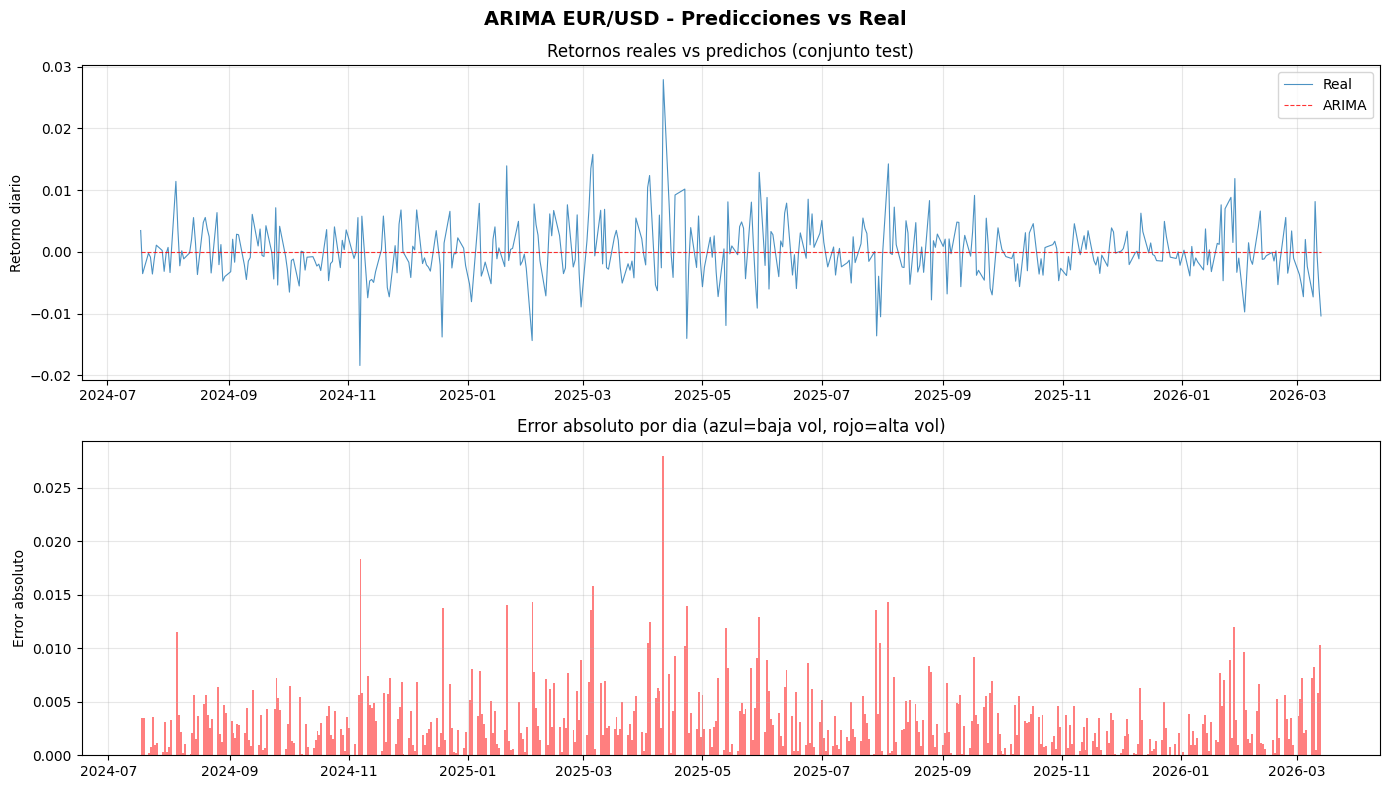

Gráfico guardado en la carpeta results


In [5]:
# Visualización predicciones vs real EUR/USD
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle("ARIMA EUR/USD - Predicciones vs Real", fontsize=14, fontweight="bold")

# Gráfico superior: serie completa
axes[0].plot(test.index, test.values, color="#1f77b4", linewidth=0.8, label="Real", alpha=0.8)
axes[0].plot(test.index, predicciones.values, color="red", linewidth=0.8, label="ARIMA", alpha=0.8, linestyle="--")
axes[0].set_title("Retornos reales vs predichos (conjunto test)")
axes[0].set_ylabel("Retorno diario")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Gráfico inferior: errores por régimen
errores = np.abs(test.values - predicciones.values)
colores_regimen = ["blue" if r == 0 else "red" for r in regimen_test_alineado.values]
axes[1].bar(test.index, errores, color=colores_regimen, alpha=0.5, width=1)
axes[1].set_title("Error absoluto por dia (azul=baja vol, rojo=alta vol)")
axes[1].set_ylabel("Error absoluto")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../results/03_arima_eurusd.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico guardado en la carpeta results")

Lo que visualizamos en las gráficas:

En el gráfico superior la línea aRIMA es completamente plana en 0 - confirma visualmente que el modelo (0,0,0) simplemente predice siempre cero, incapaz de anticipar ningún movimiento.

En el gráfico inferior se ve perfectamente que las barras rojas (alta volatilidad) son sistemáticamente más altas que las azules (baja volatilidad), especialmente los picos más extremos que coinciden todos con periodos de alta volatilidad.

# ARIMA A LOS 5 ACTIVOS

In [7]:
# ARIMA sobre los 5 activos - bucle completo
resultados_arima = []
ordenes_optimos = {}

for activo in activos:
    print(f"\nProcesando {activo.upper()}...")
    
    retornos = datos[activo]["Retorno"].dropna()
    regimen = datos[activo]["Regimen"].dropna()
    
    # Split 80/20
    split = int(len(retornos) * 0.8)
    train = retornos.iloc[:split]
    test = retornos.iloc[split:]
    regimen_test = regimen.iloc[split:].reindex(test.index)
    
    # Grid search
    mejor_aic = np.inf
    mejor_orden = (0, 0, 0)
    for p, q in product(range(4), range(4)):
        try:
            m = ARIMA(train, order=(p, 0, q)).fit()
            if m.aic < mejor_aic:
                mejor_aic = m.aic
                mejor_orden = (p, 0, q)
        except:
            continue

    ordenes_optimos[activo] = mejor_orden

    # Entrenar y predecir
    ajuste = ARIMA(train, order=mejor_orden).fit()
    predicciones = ajuste.forecast(steps=len(test))
    predicciones.index = test.index

    # Métricas globales
    mae = mean_absolute_error(test, predicciones)
    rmse = np.sqrt(mean_squared_error(test, predicciones))

    resultados_arima.append({
        "Activo": activo.upper(),
        "Orden": str(mejor_orden),
        "AIC": round(mejor_aic, 2),
        "MAE_global": round(mae, 6),
        "RMSE_global": round(rmse, 6),
        "MAE_baja_vol": None,
        "MAE_alta_vol": None,
    })

    # Métricas por régimen
    for reg_val, reg_nombre in [("Baja", "baja_vol"), ("Alta", "alta_vol")]:
        mask = regimen_test == reg_val
        if mask.sum() > 0:
            mae_r = mean_absolute_error(test[mask], predicciones[mask])
            resultados_arima[-1][f"MAE_{reg_nombre}"] = round(mae_r, 6)

    print(f" Orden: {mejor_orden} | MAE: {mae:.6f} | MAE baja: {resultados_arima[-1]['MAE_baja_vol']} | MAE alta: {resultados_arima[-1]['MAE_alta_vol']}")

# Tabla resumen
df_arima  = pd.DataFrame(resultados_arima)
print("\n\nRESUMEN ARIMA - TODOS LOS ACTIVOS")
print("=" * 80)
print(df_arima.to_string(index=False))

# Guardar
df_arima.to_csv("../results/arima_resultados.csv", index=False)
print("\nGuardado en results/arima_resultados.csv")


Procesando EURUSD...
 Orden: (0, 0, 0) | MAE: 0.003458 | MAE baja: 0.002928 | MAE alta: 0.004339

Procesando GBPUSD...
 Orden: (0, 0, 0) | MAE: 0.003538 | MAE baja: 0.00339 | MAE alta: 0.004753

Procesando USDJPY...
 Orden: (0, 0, 0) | MAE: 0.005000 | MAE baja: 0.003761 | MAE alta: 0.005763

Procesando BTC...
 Orden: (0, 0, 2) | MAE: 0.017575 | MAE baja: 0.016052 | MAE alta: 0.026622

Procesando ETH...
 Orden: (2, 0, 1) | MAE: 0.027224 | MAE baja: 0.025233 | MAE alta: 0.033176


RESUMEN ARIMA - TODOS LOS ACTIVOS
Activo     Orden       AIC  MAE_global  RMSE_global  MAE_baja_vol  MAE_alta_vol
EURUSD (0, 0, 0) -13611.21    0.003458     0.004741      0.002928      0.004339
GBPUSD (0, 0, 0) -12797.18    0.003538     0.004586      0.003390      0.004753
USDJPY (0, 0, 0) -13102.34    0.005000     0.006532      0.003761      0.005763
   BTC (0, 0, 2)  -9161.11    0.017575     0.025039      0.016052      0.026622
   ETH (2, 0, 1)  -7987.49    0.027224     0.038775      0.025233      0.033176



* Las divisas Forex tienen MAE global entre 0.0034 y 0.0050, que son errores muy pequeños pero como el modelo predice siempre 0, simplemente refleja que los retornos Forex son muy cercanos a cero en media.

* Las criptomonedas tienen MAE 5-8 veces mayor que las divisas (BTC: 0.0175, ETH: 0.0272), lo que nos confirma que ARIMA sufre muchos con activos de alta volatilidad.

* BTC y ETH sí encontraron estructura (órdenes (0,0,2) y (2,0,1) respectivamente, mientras que las divisas salieron todas (0,0,0). Esto significa que los retornos cripto tienen alguna dependencia temporal que ARIMA puede detectar, aunque sea débil)

* El patrón alta vs baja volatilidad se confirma en todos los activos sin excepción - el MAE en alta volatilidad es siempre mayor que en baja. 